In [ ]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist

In [ ]:
# loading the dataset in cache (~/.keras/datasets/mnist.npz)
(train_X, train_Y), (test_X, test_Y) = mnist.load_data()

# flatten the data from (sample_size, 28, 28) to (sample_size, 784)
train_X_flattened = train_X.reshape(train_X.shape[0], train_X.shape[1] * train_X.shape[2])
test_X_flattened = test_X.reshape(test_X.shape[0], test_X.shape[1] * test_X.shape[2])

# convert the data into dataframes for putting together the features and labels
train_df = pd.DataFrame(train_X_flattened)
train_df["label"] = train_Y
test_df = pd.DataFrame(test_X_flattened)
test_df["label"] = test_Y

# convert the dataframes into numpy arrays
train_np_array = np.array(train_df)
test_np_array = np.array(test_df)

# shuffling the data
np.random.shuffle(train_np_array)
np.random.shuffle(test_np_array)

# split the data again into features and labels
X_train = train_np_array[:, :-1]
Y_train = train_np_array[:, -1]
Y_test = test_np_array[:, -1]
X_test = test_np_array[:, :-1]

In [ ]:
# initialize the weights and biases
def init_params():
    # first layer 784 input neurons (input layer), 64 output neurons (1. hidden layer)
    w1 = np.random.randn(784, 64) * 0.01
    b1 = np.zeros((1, 64))
    
    # second layer: 64 input neurons (1. hidden layer), 32 output neurons (2. hidden layer)
    w2 = np.random.randn(64, 32) * 0.01
    b2 = np.zeros((1, 32))
    
    # third layer: 32 input neurons (2. hidden layer), 10 output neurons (output layer)
    w3 = np.random.randn(32, 10) * 0.01
    b3 = np.zeros((1, 10))
    return w1, b1, w2, b2, w3, b3

# forward propagation with X as input and the weights and biases as parameters
def forward_prop(X, w1, b1, w2, b2, w3, b3):
    # first layer output
    Z1 = np.dot(X, w1) + b1
    A1 = relu(Z1)
    
    # second layer output
    Z2 = np.dot(A1, w2) + b2
    A2 = relu(Z2)
    
    # third layer output
    Z3 = np.dot(A2, w3) + b3
    # final output with softmax activation function
    A3 = softmax(Z3)
    return Z1, A1, Z2, A2, Z3, A3

# backward propagation with X as input, the weights and biases as parameters and the output of the forward propagation
def backward_prop(X, Z1, A1, Z2, A2, Z3, A3, Y, w2, w3):
    # number of samples
    m = Y.shape[0]
    
    # convert the labels to one-hot encoding
    one_hot_Y = one_hot(Y)
    
    # calculate the gradients for the output layer
    dZ3 = A3 - one_hot_Y
    # the gradients for the weights and biases of the this layer are calculated with the output of the layer before
    dw3 = 1 / m * A2.T.dot(dZ3)
    # the gradients for the biases are calculated with the sum of the gradients of the output layer
    # we do axis=0 because we want to iterate column-wise(the features)
    db3 = 1 / m * np.sum(dZ3, axis=0, keepdims=True)
    
    # calculate the gradients for the second hidden layer
    dA2 = np.dot(dZ3, w3.T)
    dZ2 = dA2 * deriv_relu(Z2)
    dw2 = 1 / m * A1.T.dot(dZ2)
    db2 = 1 / m * np.sum(dZ2, axis=0, keepdims=True)
    
    # calculate the gradients for the first hidden layer
    dA1 = np.dot(dZ2, w2.T)
    dZ1 = dA1 * deriv_relu(Z1)
    # here we use the input X because the output of the input layer is the input data itself
    dw1 = 1 / m * X.T.dot(dZ1)
    db1 = 1 / m * np.sum(dZ1, axis=0, keepdims=True)
    return dw1, db1, dw2, db2, dw3, db3

# update the weights and biases with the gradients and the learning rate alpha
def update_params(w1, b1, w2, b2, w3, b3, dw1, db1, dw2, db2, dw3, db3, alpha):
    w1 -= alpha * dw1
    b1 -= alpha * db1
    w2 -= alpha * dw2
    b2 -= alpha * db2
    w3 -= alpha * dw3
    b3 -= alpha * db3
    return w1, b1, w2, b2, w3, b3
    
def one_hot(Y):
    # first create a zero matrix of shape (number of samples, number of classes)
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    
    # then fill the matrix with 1s at the appropriate positions
    one_hot_Y[np.arange(Y.size), Y] = 1
    return one_hot_Y
    
def relu(Z):
    # return the max of 0 and Z
    return np.maximum(0, Z)

def deriv_relu(Z):
    # the derivative of relu is 1 for Z > 0 and 0 for Z <= 0
    return (Z > 0)

def softmax(Z):
    # to prevent overflow we subtract the max of Z from Z before applying the exponential function
    # we do axis=1 because we want to iterate row-wise (the samples)
    expZ = np.exp(Z - np.max(Z, axis=1, keepdims=True))
    return expZ / np.sum(expZ, axis=1, keepdims=True)

def gradient_descent(X, Y, w1, b1, w2, b2, w3, b3, alpha):
    # first we do the forward propagation to get the output of the network
    Z1, A1, Z2, A2, Z3, A3 = forward_prop(X, w1, b1, w2, b2, w3, b3)
    
    # then we do the backward propagation to get the gradients of the weights and biases
    dw1, db1, dw2, db2, dw3, db3 = backward_prop(X, Z1, A1, Z2, A2, Z3, A3, Y, w2, w3)
    
    # finally we update the weights and biases with the gradients and the learning rate alpha
    w1, b1, w2, b2, w3, b3 = update_params(w1, b1, w2, b2, w3, b3, dw1, db1, dw2, db2, dw3, db3, alpha)
    return w1, b1, w2, b2, w3, b3 

In [182]:
def calculate_accuracy(index, X, Y, w1, b1, w2, b2, w3, b3):
    # we do the forward propagation to get the output of the network
    _, _, _, _, _, A3 = forward_prop(X, w1, b1, w2, b2, w3, b3)
    # we get the predicted labels by taking the index of the maximum value in the output layer
    predictions = np.argmax(A3, axis=1)
    # we iterate through the predictions and compare them with the true labels to calculate the accuracy
    acc = np.mean(predictions == Y)
    correct_idx = np.where(predictions == Y)[0].tolist()
    false_idx = np.where(predictions != Y)[0].tolist()
    
    return acc, correct_idx, false_idx

def print_prediction(index, X, Y, prediction):
    image = X[index].reshape(28, 28)
    predictions = np.argmax(prediction, axis=1)
    plt.imshow(image)
    plt.title("Sample " + str(index))
    plt.axis("off")
    plt.show()
    
    print(f"(rounded) Output of Neural Network: {np.round(prediction[index], 3).tolist()}")
    print(f"Predicted Label: {predictions[index]}")
    print(f"True Label: {Y[index]}")   

In [188]:
def train(modelname, iterations, alpha, w1, b1, w2, b2, w3, b3):
    for i in range(1, iterations+1):
        w1, b1, w2, b2, w3, b3 = gradient_descent(X_train, Y_train, w1, b1, w2, b2, w3, b3, alpha)
        
        if i % 5 == 0:
            print(f"Epoch {i}/{iterations} completed")
            acc, _, _ = calculate_accuracy(i, X_train, Y_train, w1, b1, w2, b2, w3, b3)
            np.savez(modelname, w1=w1, b1=b1, w2=w2, b2=b2, w3=w3, b3=b3)
            print(f"Training Accuracy: {acc*100:.2f}%")
            
    return w1, b1, w2, b2, w3, b3
            
def test(index, X_test, Y_test, w1, b1, w2, b2, w3, b3):
    _, _, _, _, _, A3 = forward_prop(X_test, w1, b1, w2, b2, w3, b3)
    print_prediction(index, X_test, Y_test, A3)
    acc, correct_idx, false_idx = calculate_accuracy(index, X_test, Y_test, w1, b1, w2, b2, w3, b3)
    print(f"Test Accuracy: {acc * 100:.2f}%")
    print(f"Wrong samples: {false_idx}")

In [ ]:
def train_model(iterations, alpha, modelname):
    if os.path.exists(modelname):
        print(f"Loading model {modelname}...")
        data = np.load(modelname)
        w1 = data["w1"]
        b1 = data["b1"]
        w2 = data["w2"]
        b2 = data["b2"]
        w3 = data["w3"]
        b3 = data["b3"]
    else:
        print(f"Creating new model {modelname}...")
        w1, b1, w2, b2, w3, b3 = init_params()
        print(f"Training new model {modelname}...")
        
    train(modelname, iterations, alpha, w1, b1, w2, b2, w3, b3)
    
def test_model(index, modelname):
    data = np.load(modelname)
    w1 = data["w1"]
    b1 = data["b1"]
    w2 = data["w2"]
    b2 = data["b2"]
    w3 = data["w3"]
    b3 = data["b3"]
    test(index, X_test, Y_test, w1, b1, w2, b2, w3, b3)

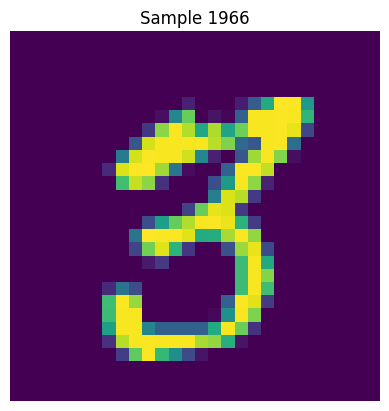

(rounded) Output of Neural Network: [0.0, 0.0, 0.002, 0.11, 0.0, 0.85, 0.0, 0.0, 0.037, 0.0]
Predicted Label: 5
True Label: 3
Test Accuracy: 96.53%
Wrong samples: [7, 35, 41, 99, 105, 211, 243, 254, 257, 283, 292, 327, 355, 377, 385, 421, 466, 469, 507, 511, 541, 583, 603, 604, 640, 652, 668, 723, 729, 816, 840, 855, 870, 886, 901, 937, 940, 969, 977, 1009, 1106, 1124, 1151, 1243, 1248, 1330, 1356, 1387, 1403, 1408, 1455, 1523, 1581, 1583, 1636, 1739, 1741, 1763, 1797, 1832, 1857, 1943, 1953, 1966, 1985, 1991, 1992, 1993, 2030, 2069, 2089, 2155, 2168, 2186, 2190, 2277, 2287, 2306, 2363, 2417, 2441, 2476, 2480, 2497, 2501, 2527, 2568, 2623, 2639, 2704, 2709, 2734, 2737, 2863, 2878, 2984, 3037, 3066, 3079, 3122, 3125, 3160, 3198, 3202, 3220, 3257, 3364, 3372, 3432, 3465, 3495, 3508, 3533, 3550, 3553, 3574, 3578, 3588, 3628, 3645, 3648, 3653, 3671, 3680, 3686, 3732, 3796, 3801, 3844, 3853, 3958, 3994, 3998, 4005, 4010, 4038, 4039, 4040, 4073, 4095, 4105, 4107, 4121, 4141, 4156, 4177, 4184

In [192]:
# train_model(iterations=800, alpha=0.015, modelname="model2.npz")
test_model(1966, modelname="model2.npz")